# Task 1.1: Application of Python-based geospatial visualisation tool (e.g., GeoPandas) on a real- world dataset 

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
refugee = pd.read_csv("data/persons_of_concern_demographics.csv")


In [3]:
refugee.head()

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60+,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
0,2001,-,Afghanistan,-,AFG,192279,304463,260994,582552,40557,6717,1387562,195602,323327,277122,785010,57395,8854,1647310,5140545
1,2001,-,Iran (Islamic Rep. of),-,IRN,1721,2794,2440,6352,458,1330,15095,1767,2961,2560,7830,560,2122,17800,106628
2,2001,-,Iraq,-,IRQ,2488,20261,17390,127005,11755,1789,180688,2501,21658,18542,185983,10963,2710,242357,578334
3,2001,-,North Macedonia,-,MKD,1019,2088,1805,8080,1383,74,14449,1159,2234,1933,7255,1190,86,13857,30788
4,2001,-,Serbia and Kosovo: S/RES/1244 (1999),-,SRB,8657,15563,13329,65421,17376,7864,128210,9303,16535,14165,65563,13779,9573,128918,543654


In [4]:
refugee.columns

Index(['Year', 'Country of Asylum', 'Country of Origin',
       'Country of Asylum ISO', 'Country of Origin ISO', 'Female 0 - 4',
       'Female 5 - 11', 'Female 12 - 17', 'Female 18 - 59', 'Female 60+',
       'Female Other', 'Female Total', 'Male 0 - 4', 'Male 5 - 11',
       'Male 12 - 17', 'Male 18 - 59', 'Male 60+', 'Male Other', 'Male Total',
       'Total'],
      dtype='str')

In [5]:
refugee.describe()


,Year,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60+,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
count,4661.000000,4661.000000,4.661000e+03,4.661000e+03,4.661000e+03,4661.000000,4.661000e+03,4.661000e+03,4661.000000,4.661000e+03,4.661000e+03,4.661000e+03,4661.000000,4.661000e+03,4.661000e+03,4.661000e+03
mean,2012.732246,7944.582278,1.166187e+04,8.662124e+03,2.972893e+04,3544.249517,2.198520e+04,8.352696e+04,8072.672602,1.201343e+04,9.112376e+03,2.958149e+04,3177.455911,2.140380e+04,8.336123e+04,2.780156e+05
std,6.943670,47612.449305,6.817692e+04,4.977553e+04,1.714929e+05,28063.598895,1.841374e+05,4.128308e+05,48377.248303,7.049394e+04,5.160432e+04,1.652293e+05,23373.433865,1.740902e+05,4.032877e+05,1.319654e+06
min,2001.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,5.000000e+00
25%,2007.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,7.000000e+00,0.000000,0.000000e+00,0.000000e+00,5.000000e+00,0.000000,0.000000e+00,9.000000e+00,1.760000e+02
50%,2013.000000,5.000000,8.000000e+00,8.000000e+00,4.800000e+01,0.000000,1.600000e+01,1.580000e+02,5.000000,8.000000e+00,8.000000e+00,7.700000e+01,0.000000,2.100000e+01,2.080000e+02,2.112000e+03
75%,2019.000000,144.000000,2.320000e+02,1.880000e+02,1.262000e+03,82.000000,3.440000e+02,4.067000e+03,143.000000,2.440000e+02,2.200000e+02,1.951000e+03,97.000000,6.050000e+02,5.643000e+03,3.446300e+04
max,2024.000000,878613.000000,1.660594e+06,1.096779e+06,3.182316e+06,837457.000000,4.323970e+06,7.220071e+06,895400.000000,1.682751e+06,1.116633e+06,2.704253e+06,680577.000000,4.087720e+06,7.092986e+06,3.000298e+07


In [6]:
print("Total raws:", refugee.shape[0])

Total raws: 4661


In [7]:
refugee.duplicated().sum()

np.int64(0)

In [8]:
refugee.isna().sum()

Year                     0
Country of Asylum        0
Country of Origin        0
Country of Asylum ISO    0
Country of Origin ISO    0
Female 0 - 4             0
Female 5 - 11            0
Female 12 - 17           0
Female 18 - 59           0
Female 60+               0
Female Other             0
Female Total             0
Male 0 - 4               0
Male 5 - 11              0
Male 12 - 17             0
Male 18 - 59             0
Male 60+                 0
Male Other               0
Male Total               0
Total                    0
dtype: int64

# Data reprocessing 

In [9]:
refugee_df = refugee[['Year', 'Country of Origin ISO', 'Country of Origin', 'Total']]

In [10]:
refugee_df = refugee_df.rename(columns={
    'Country of Origin ISO': 'ISO_A3',
    'Country of Origin': 'Country',
    'Total': 'Total_Refugees'
})

In [11]:
refugee_2004 = refugee_df[refugee['Year'] == 2004]
refugee_2024 = refugee_df[refugee['Year'] == 2024]

In [12]:
refugee_2004.head()

,Year,ISO_A3,Country,Total_Refugees
562,2004,AFG,Afghanistan,2691054
563,2004,IRN,Iran (Islamic Rep. of),124690
564,2004,IRQ,Iraq,358647
565,2004,MKD,North Macedonia,5801
566,2004,SRB,Serbia and Kosovo: S/RES/1244 (1999),579815


In [13]:
refugee_2024.head()

,Year,ISO_A3,Country,Total_Refugees
4454,2024,COL,Colombia,8357371
4455,2024,VEN,Venezuela (Bolivarian Republic of),8416439
4456,2024,AFG,Afghanistan,10822549
4457,2024,BGD,Bangladesh,681340
4458,2024,IND,India,242491


In [14]:
countries = gpd.read_file("data/ne_110m_admin_0_countries.shp")

In [15]:
countries.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [16]:
countries_gdf = countries[['ISO_A3', 'ADMIN', 'CONTINENT', 'REGION_WB', 'geometry']]

In [17]:
list(countries.columns)  #make sure the has ISO_A3 column

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'TLC',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'FIPS_10',
 'ISO_A2',
 'ISO_A2_EH',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'ISO_N3_EH',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_ISO',
 'ADM0_DIFF',
 'ADM0_TLC',
 'ADM0_A3_US',
 'ADM0_A3_FR',
 'ADM0_A3_RU',
 'ADM0_A3_ES',
 'ADM0_A3_CN',
 'ADM0_A3_TW',
 'ADM0_A3_IN',
 'ADM0_A3_NP',
 'ADM0_A3_PK',
 'ADM0_A3_DE',
 'ADM0_A3_GB',
 'ADM0_A3_BR',
 'ADM0_A3_IL',
 'ADM0_A3_PS',
 'ADM0_A3_SA',
 'ADM0_A3_EG',
 'ADM0_A3_MA',
 'ADM0_A3_PT

In [18]:
countries_gdf.head()

,ISO_A3,ADMIN,CONTINENT,REGION_WB,geometry
0,FJI,Fiji,Oceania,East Asia & Pacific,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,TZA,United Republic of Tanzania,Africa,Sub-Saharan Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,ESH,Western Sahara,Africa,Middle East & North Africa,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,CAN,Canada,North America,North America,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,USA,United States of America,North America,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [19]:
geo_2004 = countries_gdf.merge(refugee_2004, on='ISO_A3', how='left')

In [20]:
geo_2004.head()

,ISO_A3,ADMIN,CONTINENT,REGION_WB,geometry,Year,Country,Total_Refugees
0,FJI,Fiji,Oceania,East Asia & Pacific,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",2004.0,Fiji,1800.0
1,TZA,United Republic of Tanzania,Africa,Sub-Saharan Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",2004.0,United Rep. of Tanzania,5321.0
2,ESH,Western Sahara,Africa,Middle East & North Africa,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",2004.0,Western Sahara,191741.0
3,CAN,Canada,North America,North America,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",2004.0,Canada,75.0
4,USA,United States of America,North America,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",2004.0,United States of America,717.0


In [21]:
geo_2024 = countries_gdf.merge(refugee_2024, on='ISO_A3', how='left')

In [22]:
geo_2024.head()

,ISO_A3,ADMIN,CONTINENT,REGION_WB,geometry,Year,Country,Total_Refugees
0,FJI,Fiji,Oceania,East Asia & Pacific,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",2024.0,Fiji,3416.0
1,TZA,United Republic of Tanzania,Africa,Sub-Saharan Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",2024.0,United Rep. of Tanzania,5169.0
2,ESH,Western Sahara,Africa,Middle East & North Africa,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",2024.0,Western Sahara,175445.0
3,CAN,Canada,North America,North America,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",2024.0,Canada,660.0
4,USA,United States of America,North America,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",2024.0,United States of America,6413.0


In [23]:
geo_2004['Total_Refugees'] = geo_2004['Total_Refugees'].fillna(0)
geo_2024['Total_Refugees'] = geo_2024['Total_Refugees'].fillna(0)

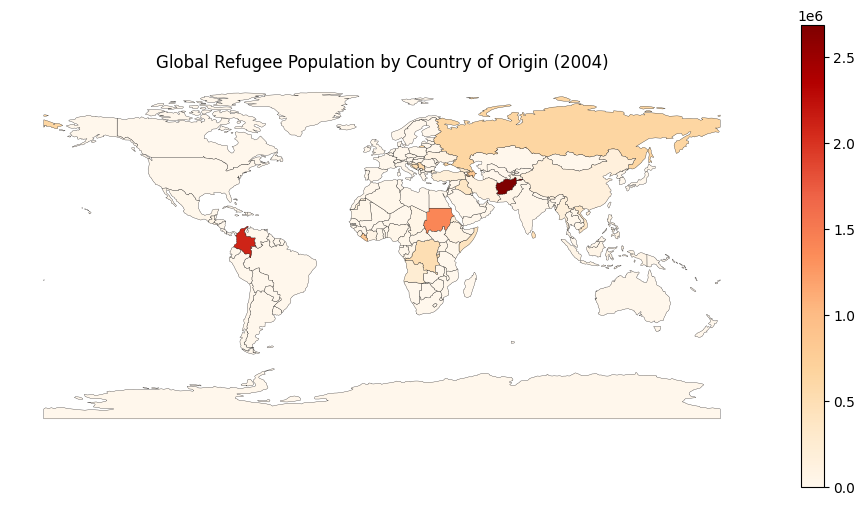

In [24]:
geo_2004.plot(
    column='Total_Refugees',
    cmap='OrRd',
    legend=True,
    figsize=(12,6),
    edgecolor='black',
    linewidth=0.2,
    missing_kwds={"color": "lightgrey"}
)

plt.title("Global Refugee Population by Country of Origin (2004)")
plt.axis('off')
plt.show()

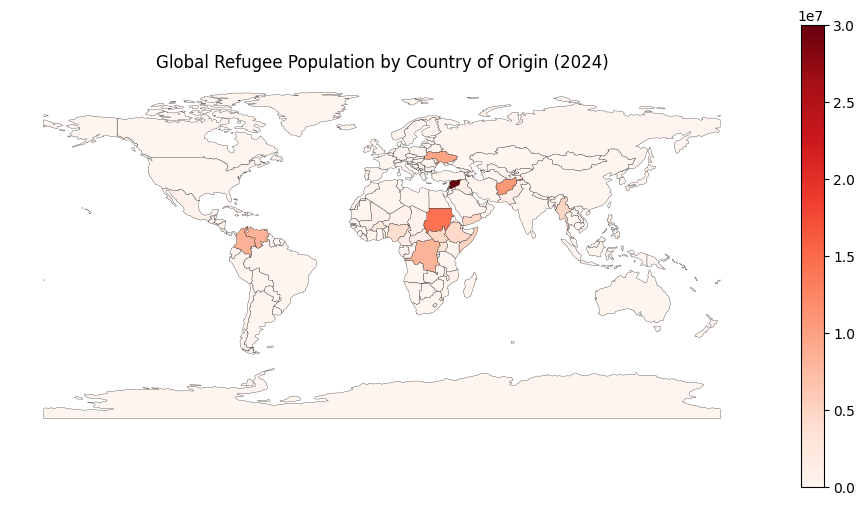

In [25]:
geo_2024.plot(
    column='Total_Refugees',
    cmap='Reds',
    legend=True,
    figsize=(12,6),
    edgecolor='black',
    linewidth=0.2,
    missing_kwds={"color": "lightgrey"}
)

plt.title("Global Refugee Population by Country of Origin (2024)")
plt.axis('off')
plt.show()

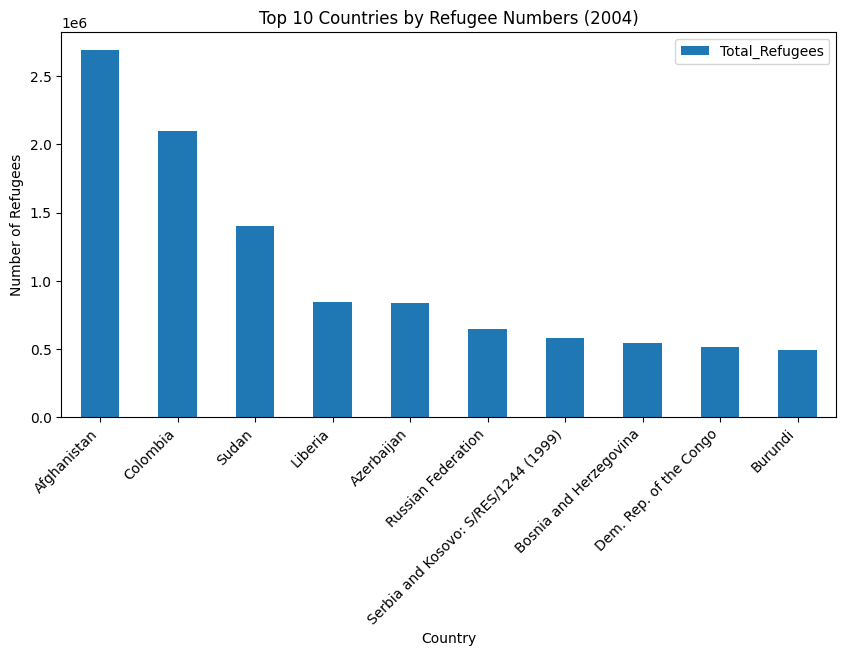

In [26]:
map_2004 = geo_2004.sort_values(by='Total_Refugees', ascending=False).head(10)

map_2004.plot(
    x='Country',
    y='Total_Refugees',
    kind='bar',
    figsize=(10,5),
    title='Top 10 Countries by Refugee Numbers (2004)'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Refugees")
plt.show()


# Inference 1 (2004)

## The bar chart for 2004 shows that Afghanistan had the highest number of refugees, followed by Colombia and Sudan. This indicates that during this period, refugee movements were strongly influenced by regi=onal conflicts and political instability in these countries. The distribution also shows that a relatively small number of countries accounted for a large share of global refugee populations.

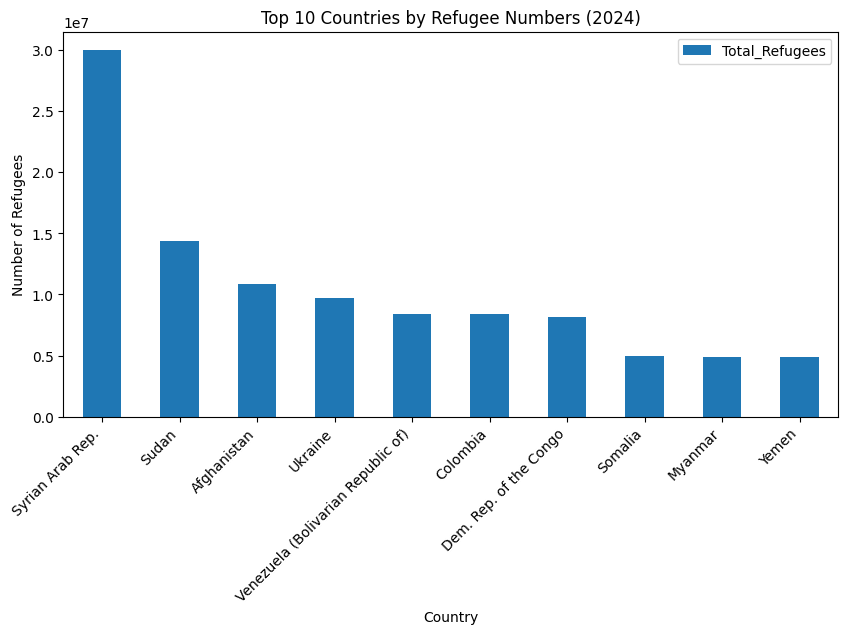

In [27]:
map_2024 = geo_2024.sort_values(by='Total_Refugees', ascending=False).head(10)

map_2024.plot(
    x='Country',
    y='Total_Refugees',
    kind='bar',
    figsize=(10,5),
    title='Top 10 Countries by Refugee Numbers (2024)'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Refugees")
plt.show()



# Inference 2 (2024)

## The chart for 2024 shows a significant shift in refugee patterns, with Syria having the highest refugee numbers, followed by Sudan and Afghanistan. This reflects the impact of more recent conflicts and humanitarian crises, particularly the Syrian civil war and ongoing instability in several regions. The results highlight how refugee distribution changes over time due to evolving geopolitical and social conditions.

# Task 1.2: Analysis of geospatial datasets 

In [28]:
conflict = pd.read_csv("data/GEDEvent_v25_1.csv")
conflict.head()



C:\Users\Jamal Amro\AppData\Local\Temp\ipykernel_34840\3209839319.py:1: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  conflict = pd.read_csv("data/GEDEvent_v25_1.csv")


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29 00:00:00.000,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN


In [29]:
conflict.columns

Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')

In [30]:
conflict.info()

<class 'pandas.DataFrame'>
RangeIndex: 385918 entries, 0 to 385917
Data columns (total 49 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 385918 non-null  int64  
 1   relid              385918 non-null  str    
 2   year               385918 non-null  int64  
 3   active_year        385918 non-null  bool   
 4   code_status        385918 non-null  str    
 5   type_of_violence   385918 non-null  int64  
 6   conflict_dset_id   385918 non-null  int64  
 7   conflict_new_id    385918 non-null  int64  
 8   conflict_name      385918 non-null  str    
 9   dyad_dset_id       385918 non-null  int64  
 10  dyad_new_id        385918 non-null  int64  
 11  dyad_name          385918 non-null  str    
 12  side_a_dset_id     385918 non-null  int64  
 13  side_a_new_id      385918 non-null  int64  
 14  side_a             385918 non-null  str    
 15  side_b_dset_id     385918 non-null  int64  
 16  side_b_new_id

In [31]:
conflict = conflict[['year', 'country', 'best', 'latitude', 'longitude']]


In [32]:
conflict.rename(columns={'best': 'Total_Deaths'}, inplace=True)

In [33]:
import geopandas as gpd
from shapely.geometry import Point

conflict['geometry'] = conflict.apply(
    lambda row: Point(row['longitude'], row['latitude']),
    axis=1
)

conflict_gdf = gpd.GeoDataFrame(conflict, geometry='geometry')
conflict_gdf.set_crs(epsg=4326, inplace=True)

,year,country,Total_Deaths,latitude,longitude,geometry
0,2017,Afghanistan,6,34.531094,69.162796,POINT (69.1628 34.53109)
1,2021,Afghanistan,183,34.564444,69.217222,POINT (69.21722 34.56444)
2,2021,Afghanistan,2,34.428844,70.455750,POINT (70.45575 34.42884)
3,2021,Afghanistan,10,34.531094,69.162796,POINT (69.1628 34.53109)
4,1989,Afghanistan,6,34.333330,70.416670,POINT (70.41667 34.33333)
...,...,...,...,...,...,...
385913,1989,Zimbabwe (Rhodesia),9,-20.500000,32.500000,POINT (32.5 -20.5)
385914,1989,Zimbabwe (Rhodesia),9,-19.000000,32.500000,POINT (32.5 -19)
385915,1990,Zimbabwe (Rhodesia),7,-18.000000,32.833333,POINT (32.83333 -18)
385916,1990,Zimbabwe (Rhodesia),1,-19.000000,32.500000,POINT (32.5 -19)


In [34]:
conflict_2024 = conflict_gdf[conflict_gdf['year'] == 2024]

In [35]:
conflict_joined = gpd.sjoin(
    conflict_2024,
    countries_gdf,
    how='inner',   # ✅ better
    predicate='within'
)

In [36]:
conflict_joined.head()

,year,country,Total_Deaths,latitude,longitude,geometry,index_right,ISO_A3,ADMIN,CONTINENT,REGION_WB
37445,2024,Afghanistan,3,33.995289,69.022740,POINT (69.02274 33.99529),103,AFG,Afghanistan,Asia,South Asia
37446,2024,Afghanistan,4,31.934378,68.834517,POINT (68.83452 31.93438),103,AFG,Afghanistan,Asia,South Asia
37447,2024,Afghanistan,8,32.588040,68.725300,POINT (68.7253 32.58804),103,AFG,Afghanistan,Asia,South Asia
37448,2024,Afghanistan,51,32.713324,69.276140,POINT (69.27614 32.71332),103,AFG,Afghanistan,Asia,South Asia
38056,2024,Afghanistan,0,33.371800,66.276400,POINT (66.2764 33.3718),103,AFG,Afghanistan,Asia,South Asia


In [37]:
# Groups all conflict events by country
conflict_agg = conflict_joined.groupby('ISO_A3')['Total_Deaths'].sum().reset_index()

In [38]:
final_data = geo_2024.merge(conflict_agg, on='ISO_A3', how='left')

final_data['Total_Deaths'] = final_data['Total_Deaths'].fillna(0)

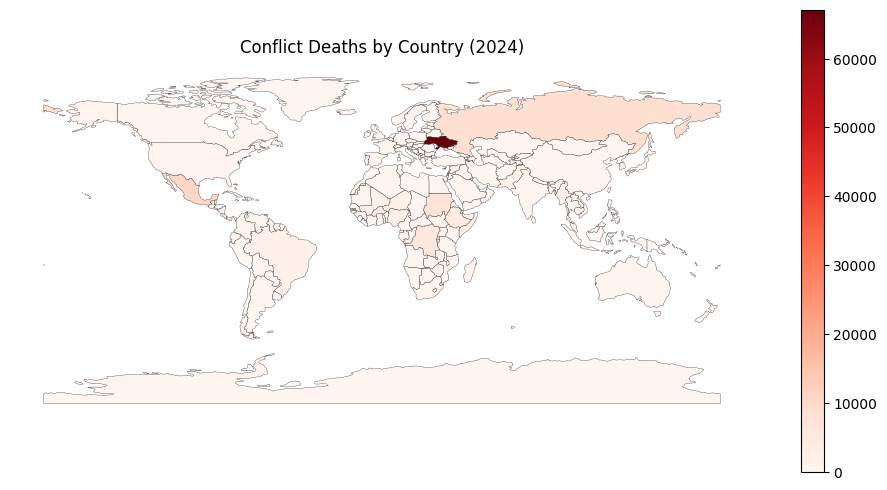

In [39]:
final_data.plot(
    column='Total_Deaths',
    cmap='Reds',
    legend=True,
    figsize=(12,6),
    edgecolor='black',
    linewidth=0.2
)

plt.title("Conflict Deaths by Country (2024)")
plt.axis('off')
plt.show()

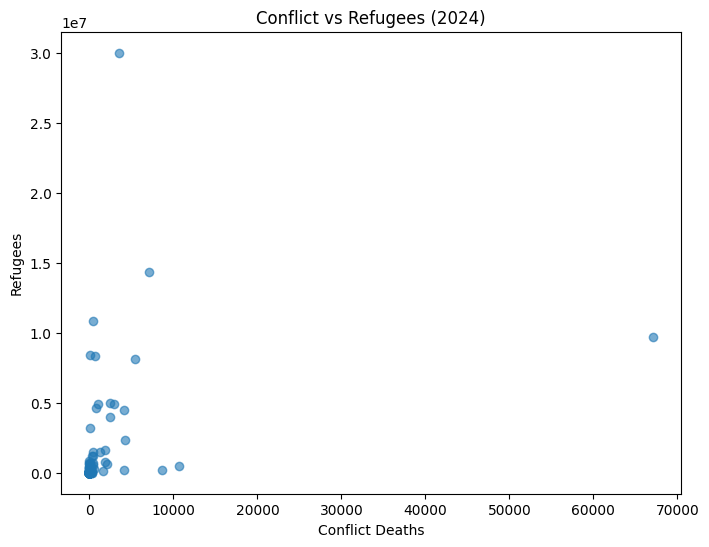

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_data['Total_Deaths'],
    final_data['Total_Refugees'],
    alpha=0.6
)

plt.xlabel("Conflict Deaths")
plt.ylabel("Refugees")
plt.title("Conflict vs Refugees (2024)")

plt.show()

# TASK 1.2.1

In [41]:
conflict_since_2000 = conflict[conflict['year'] >= 2000]  #FILTER SINCE 2000 

In [42]:
conflict_counts = conflict_since_2000.groupby('country').size().reset_index(name='conflict_count')   #COUNT CONFLICT EVENTS

In [43]:
high_conflict = conflict_counts[conflict_counts['conflict_count'] > 5000]  #FILTER > 5000 

In [44]:
high_conflict = high_conflict.rename(columns={'country': 'ADMIN'})         #MATCH WITH SHAPEFILE (GET ISO_A3)

high_conflict_geo = countries_gdf.merge(high_conflict, on='ADMIN', how='inner') 

In [45]:
high_conflict_codes = high_conflict_geo['ISO_A3']  # GET COUNTRY CODES

In [46]:
filtered_geo_2024 = geo_2024[geo_2024['ISO_A3'].isin(high_conflict_codes)] # FILTER REFUGEE (2024)

In [47]:
filtered_geo_2024.columns

Index(['ISO_A3', 'ADMIN', 'CONTINENT', 'REGION_WB', 'geometry', 'Year',
       'Country', 'Total_Refugees'],
      dtype='str')

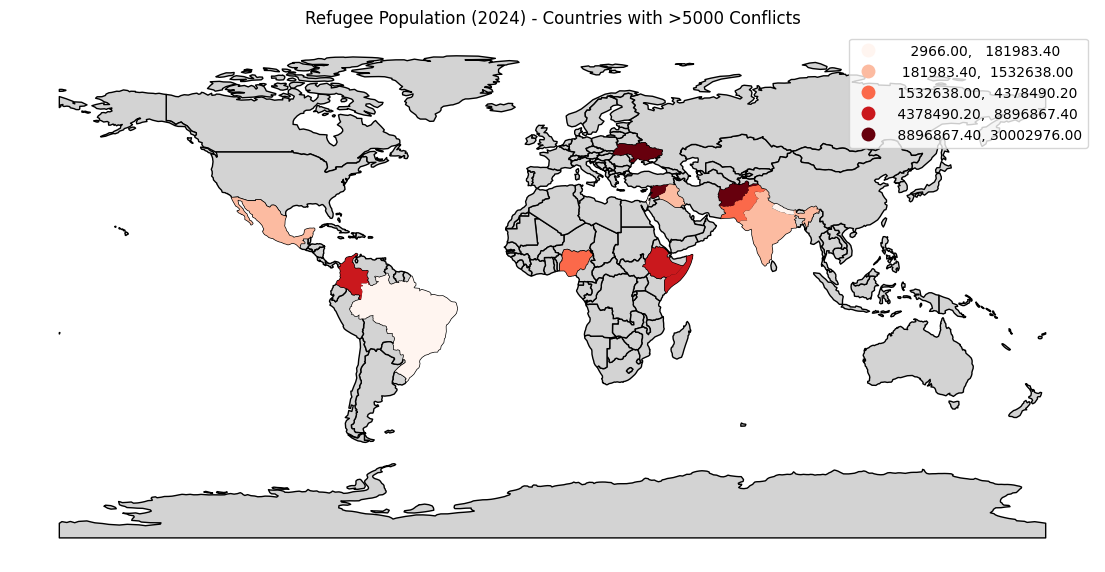

In [48]:
ax = countries_gdf.plot(
    color='lightgrey',
    edgecolor='black',
    figsize=(14,7)
)

filtered_geo_2024.plot(
    column='Total_Refugees',
    cmap='Reds',
    legend=True,
    scheme='quantiles',
    k=5,
    ax=ax
)

plt.title("Refugee Population (2024) - Countries with >5000 Conflicts")
plt.axis('off')
plt.show()

## The choropleth map shows that countries with a high number of conflicts since 2000 tend to have significantly larger refugee populations in 2024. This indicates a strong relationship between prolonged conflict and forced displacement. The highest concentrations are observed in regions such as the Middle East and parts of Africa, where ongoing instability has contributed to sustained refugee outflows.

## start 1.2.2

In [49]:
refugee.columns

Index(['Year', 'Country of Asylum', 'Country of Origin',
       'Country of Asylum ISO', 'Country of Origin ISO', 'Female 0 - 4',
       'Female 5 - 11', 'Female 12 - 17', 'Female 18 - 59', 'Female 60+',
       'Female Other', 'Female Total', 'Male 0 - 4', 'Male 5 - 11',
       'Male 12 - 17', 'Male 18 - 59', 'Male 60+', 'Male Other', 'Male Total',
       'Total'],
      dtype='str')

In [50]:
#FILTER REFUGEE DATA (2024 + FEMALE + >50,000)
# Filter correctly
female_filtered = refugee[
    (refugee['Year'] == 2024) &
    (refugee['Female Total'] > 50000)
]

# Display
female_filtered[['Country of Origin', 'Female Total']].head()

,Country of Origin,Female Total
4454,Colombia,3918323
4455,Venezuela (Bolivarian Republic of),3246913
4456,Afghanistan,5239926
4459,Iran (Islamic Rep. of),76292
4466,Stateless,1091531


In [51]:
#FILTER MIDDLE EAST (FROM SHAPE FILE)
middle_east = countries_gdf[
    countries_gdf['REGION_WB'] == 'Middle East & North Africa'
]

In [52]:
countries_gdf.head(100)


,ISO_A3,ADMIN,CONTINENT,REGION_WB,geometry
0,FJI,Fiji,Oceania,East Asia & Pacific,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,TZA,United Republic of Tanzania,Africa,Sub-Saharan Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,ESH,Western Sahara,Africa,Middle East & North Africa,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,CAN,Canada,North America,North America,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,USA,United States of America,North America,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...,...,...,...
95,PRK,North Korea,Asia,East Asia & Pacific,"MULTIPOLYGON (((130.78 42.22001, 130.78 42.220..."
96,KOR,South Korea,Asia,East Asia & Pacific,"POLYGON ((126.17476 37.74969, 126.23734 37.840..."
97,MNG,Mongolia,Asia,East Asia & Pacific,"POLYGON ((87.75126 49.2972, 88.80557 49.47052,..."
98,IND,India,Asia,South Asia,"POLYGON ((97.32711 28.26158, 97.40256 27.88254..."


In [53]:
countries_gdf['ADMIN'].unique()

<ArrowStringArray>
[                       'Fiji', 'United Republic of Tanzania',
              'Western Sahara',                      'Canada',
    'United States of America',                  'Kazakhstan',
                  'Uzbekistan',            'Papua New Guinea',
                   'Indonesia',                   'Argentina',
 ...
                  'Somaliland',                      'Uganda',
                      'Rwanda',      'Bosnia and Herzegovina',
             'North Macedonia',          'Republic of Serbia',
                  'Montenegro',                      'Kosovo',
         'Trinidad and Tobago',                 'South Sudan']
Length: 177, dtype: str

In [54]:
countries_gdf[
    countries_gdf['REGION_WB'] == 'Middle East & North Africa'
]['ADMIN']

2            Western Sahara
76                   Israel
77                  Lebanon
79                Palestine
81                  Tunisia
82                  Algeria
83                   Jordan
84     United Arab Emirates
85                    Qatar
86                   Kuwait
87                     Iraq
88                     Oman
107                    Iran
108                   Syria
157                   Yemen
158            Saudi Arabia
162                 Morocco
163                   Egypt
164                   Libya
166                Djibouti
Name: ADMIN, dtype: str

In [55]:
# Define Middle East countries (from your shapefile)
middle_east_countries = [
    'Israel',
    'Lebanon',
    'Palestine',
    'Jordan',
    'United Arab Emirates',
    'Qatar',
    'Kuwait',
    'Iraq',
    'Oman',
    'Iran',
    'Syria',
    'Yemen',
    'Saudi Arabia'
]

# Filter Middle East only
middle_east_only = countries_gdf[
    countries_gdf['ADMIN'].isin(middle_east_countries)
]

In [56]:
# MERGE REFUGEE + SHAPE 
geo_me = middle_east_only.merge(
    female_filtered,
    left_on='ISO_A3',
    right_on='Country of Origin ISO',
    how='inner'
)

In [57]:
conflict_counts = conflict_joined.groupby('ISO_A3').size().reset_index(name='Conflict_Count')  #GET CONFLICT COUNTS (FROM YOUR SPATIAL JOIN)

In [58]:
# MERGE EVERYTHING
final_me = geo_me.merge(conflict_counts, on='ISO_A3', how='left')

final_me['Conflict_Count'] = final_me['Conflict_Count'].fillna(0)

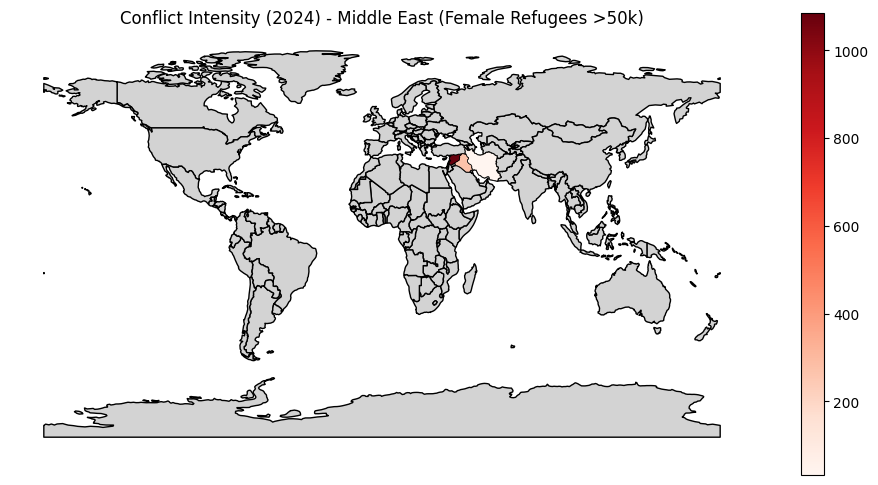

In [59]:
fig, ax = plt.subplots(figsize=(12,6))

countries_gdf.plot(color='lightgrey', edgecolor='black', ax=ax)

final_me.plot(
    column='Conflict_Count',
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_title("Conflict Intensity (2024) - Middle East (Female Refugees >50k)")
ax.set_axis_off()

plt.show()

## The map shows that conflict intensity in 2024 is concentrated in a few Middle Eastern countries with high female refugee populations. Countries experiencing prolonged instability exhibit higher conflict counts, highlighting the strong relationship between conflict and displacement patterns in the region.

# Task 1.2.3 

In [60]:
refugee['Children_0_4'] = refugee['Female 0 - 4'] + refugee['Male 0 - 4'] # CREATE CHILDREN COLUMN

In [61]:
refugee_period = refugee[(refugee['Year'] >= 2004) & (refugee['Year'] <= 2024)] # FILTER YEARS (2004–2024) 

In [62]:
children_by_country = refugee_period.groupby('Country of Origin ISO')['Children_0_4'].sum().reset_index() # AGGREGATE TOTAL PER COUNTRY

In [63]:
top5_children = children_by_country.sort_values(by='Children_0_4', ascending=False).head(5) #GET TOP 5 COUNTRIES

In [64]:
#ADD COUNTRY NAMES (OPTIONAL BUT NICE)
top5_children = top5_children.merge(
    countries_gdf[['ISO_A3','ADMIN']],
    left_on='Country of Origin ISO',
    right_on='ISO_A3',
    how='left'
)

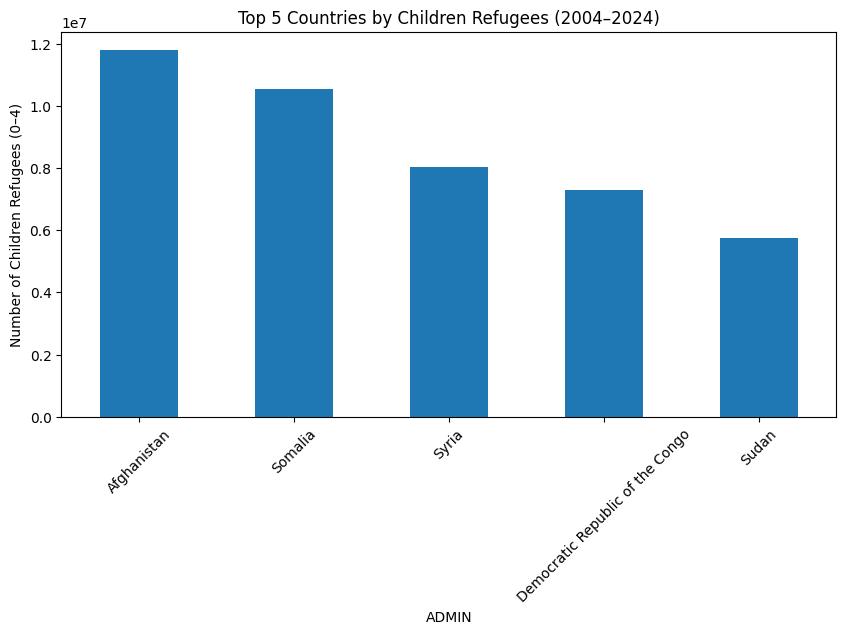

In [65]:
top5_children.plot(
    x='ADMIN',
    y='Children_0_4',
    kind='bar',
    figsize=(10,5),
    title='Top 5 Countries by Children Refugees (2004–2024)',
    legend=False
)

plt.ylabel("Number of Children Refugees (0–4)")
plt.xticks(rotation=45)
plt.show()

In [66]:
# FILTER CONFLICT DATA (2004–2024)
conflict_period = conflict_gdf[
    (conflict_gdf['year'] >= 2004) & (conflict_gdf['year'] <= 2024)
]

In [67]:
conflict_counts = conflict_joined.groupby('ISO_A3').size().reset_index(name='Total_Conflicts') # COUNT CONFLICTS PER COUNTRY

In [68]:
#MERGE WITH TOP 5
top5_final = top5_children.merge(
    conflict_counts,
    left_on='Country of Origin ISO',
    right_on='ISO_A3',
    how='left'
)

top5_final['Total_Conflicts'] = top5_final['Total_Conflicts'].fillna(0)

In [69]:
top5_final[['ADMIN','Children_0_4','Total_Conflicts']]

,ADMIN,Children_0_4,Total_Conflicts
0,Afghanistan,11794098,181
1,Somalia,10545334,171
2,Syria,8030809,1085
3,Democratic Republic of the Congo,7293447,783
4,Sudan,5763713,702


## The results show that the countries with the highest number of child refugees between 2004 and 2024 are also among those experiencing prolonged conflict. This highlights the strong relationship between conflict intensity and the displacement of vulnerable populations, particularly children. Countries with sustained instability tend to produce higher numbers of young refugees over time.

# Task 1.2.4 

In [70]:
#country with highest conflicts
top_country = top5_final.sort_values(by='Total_Conflicts', ascending=False).iloc[0]
top_country_iso = top_country['Country of Origin ISO']
top_country_name = top_country['ADMIN']

In [71]:
# Filter refugee data for this country (2004–2024)
country_refugee = refugee[
    (refugee['Country of Origin ISO'] == top_country_iso) &
    (refugee['Year'] >= 2004) &
    (refugee['Year'] <= 2024)
]

In [72]:
country_refugee.columns


Index(['Year', 'Country of Asylum', 'Country of Origin',
       'Country of Asylum ISO', 'Country of Origin ISO', 'Female 0 - 4',
       'Female 5 - 11', 'Female 12 - 17', 'Female 18 - 59', 'Female 60+',
       'Female Other', 'Female Total', 'Male 0 - 4', 'Male 5 - 11',
       'Male 12 - 17', 'Male 18 - 59', 'Male 60+', 'Male Other', 'Male Total',
       'Total', 'Children_0_4'],
      dtype='str')

In [73]:
# Aggregate refugee population per year 
yearly_refugee = country_refugee.groupby('Year')['Total'].sum().reset_index()

In [74]:
# Calculate percentage change 
yearly_refugee['Pct_Change'] = yearly_refugee['Total'].pct_change() * 100

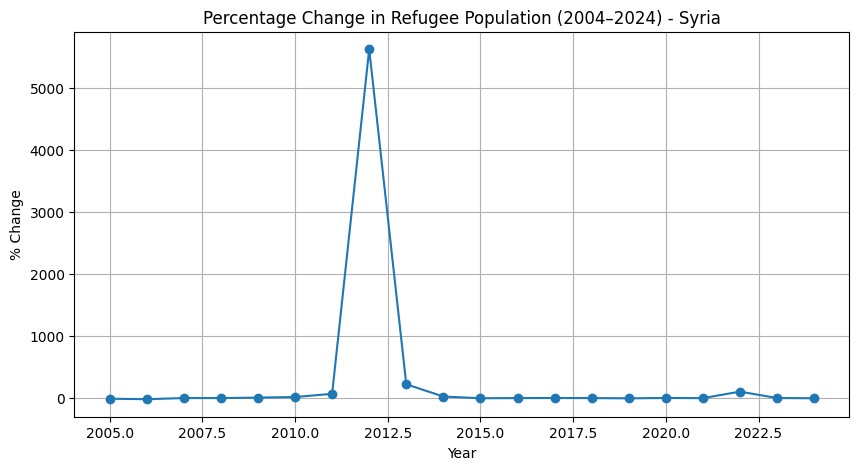

In [75]:
# 
plt.figure(figsize=(10,5))

plt.plot(yearly_refugee['Year'], yearly_refugee['Pct_Change'], marker='o')

plt.title(f"Percentage Change in Refugee Population (2004–2024) - {top_country_name}")
plt.xlabel("Year")
plt.ylabel("% Change")
plt.grid(True)

plt.show()

## The plot shows a sharp increase in refugee population around 2012, corresponding to the escalation of the Syrian conflict. The percentage change is extremely high due to a rapid increase from a relatively low base in previous years. After this spike, the trend stabilizes with smaller fluctuations, indicating a more consistent level of refugee movement over time.

# Task 1.2.5

In [76]:
# Get top conflict country (since 2010)
conflict_2010 = conflict_joined[conflict_joined['year'] >= 2010]

conflict_counts_2010 = conflict_2010.groupby('ISO_A3').size().reset_index(name='Total_Conflicts')

top_country_2010 = conflict_counts_2010.sort_values(by='Total_Conflicts', ascending=False).iloc[0]

top_iso = top_country_2010['ISO_A3']

In [77]:
#Get that country geometry
top_country_geom = countries_gdf[countries_gdf['ISO_A3'] == top_iso]

In [78]:
# Project CRS 
countries_proj = countries_gdf.to_crs(epsg=3857)
top_country_proj = top_country_geom.to_crs(epsg=3857)

In [79]:
# Create 1000 km buffer 
buffer_1000km = top_country_proj.buffer(1000000)  # meters

In [80]:
# Find neighbouring countries inside buffer 
neighbors = countries_proj[countries_proj.intersects(buffer_1000km.iloc[0])]

In [81]:
# Get refugee data (2024) 
neighbors_geo = neighbors.merge(
    refugee_2024,
    left_on='ISO_A3',
    right_on='ISO_A3',
    how='left'
)

In [82]:
refugee_2024.columns

Index(['Year', 'ISO_A3', 'Country', 'Total_Refugees'], dtype='str')

In [83]:
# Calculate distance from center 
top_center = top_country_proj.geometry.centroid.iloc[0]

neighbors_geo['Distance_km'] = neighbors_geo.geometry.centroid.distance(top_center) / 1000

In [84]:
neighbors_geo = neighbors_geo.merge(
    geo_2024[['ISO_A3', 'Total_Refugees']],
    on='ISO_A3',
    how='left'
)

In [85]:
neighbors_geo.columns

Index(['ISO_A3', 'ADMIN', 'CONTINENT', 'REGION_WB', 'geometry', 'Year',
       'Country', 'Total_Refugees_x', 'Distance_km', 'Total_Refugees_y'],
      dtype='str')

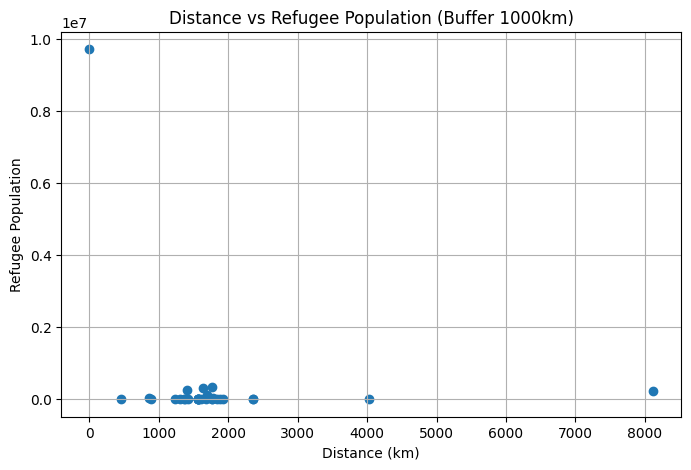

In [86]:
plt.figure(figsize=(8,5))

plt.scatter(neighbors_geo['Distance_km'], neighbors_geo['Total_Refugees_y'])

plt.xlabel("Distance (km)")
plt.ylabel("Refugee Population")
plt.title("Distance vs Refugee Population (Buffer 1000km)")

plt.grid(True)
plt.show()

# Geospatial Sentiment Analysis Using Social Media Data 

In [87]:
tweets = pd.read_csv("data/tweets_ai.csv")

## Task 2.1: Data Pre-processing 

In [88]:
# aggregate data and keep only required columns
tweets = tweets[['tweet', 'user_location', 'user_followers', 'user_verified']]

In [89]:
#Remove missing locations
tweets = tweets.dropna(subset=['user_location'])

In [90]:
# Filter users
tweets = tweets[
    (tweets['user_verified'] == True) &
    (tweets['user_followers'] >= 50)
]

In [91]:
# Clean tweet text (remove rubbish) 
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"#\S+", "", text)      # remove hashtags
    text = re.sub(r"@\S+", "", text)      # remove mentions
    text = re.sub(r"[^A-Za-z\s]", "", text)  # remove symbols
    return text.lower()

tweets['clean_tweet'] = tweets['tweet'].apply(clean_text)

In [92]:
# Take random sample (500 tweets)
tweets_sample = tweets.sample(n=500, random_state=42)

In [93]:
len(tweets_sample)

500

In [94]:
tweets_sample.head()

,tweet,user_location,user_followers,user_verified,clean_tweet
8051,Interesting Read: 4 Models for Using #Artifici...,Singapore,1083974,True,interesting read models for using to make
2273,#VoiceOfWipro #WiproHOLMES #ArtificialIntellig...,South Asia,3741,True,
1525,How Artificial Intelligence Will Redefine Mana...,"Washington, DC",3875,True,how artificial intelligence will redefine mana...
2693,"The Advertising Industry Shouldn’t Fear AI, It...",Malaysia,734665,True,the advertising industry shouldnt fear ai it s...
6029,"Artificial Intelligence: Legal, ethical, and p...",Malaysia,740458,True,artificial intelligence legal ethical and poli...


In [95]:
tweets_sample.columns

Index(['tweet', 'user_location', 'user_followers', 'user_verified',
       'clean_tweet'],
      dtype='str')

In [96]:
tweets_sample[['user_verified', 'user_followers']].describe()

,user_followers
count,5.000000e+02
mean,3.664739e+05
std,9.655819e+05
min,6.700000e+01
25%,1.315250e+04
50%,5.582200e+04
75%,6.024002e+05
max,1.371493e+07


## Task 2.2 — Geocoding

In [97]:
# Import + setup
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="geo_analysis")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [98]:
# Apply geocoding
# tweets_sample['location_data'] = tweets_sample['user_location'].apply(geocode)

In [99]:
tweets_sample = tweets_sample.dropna(subset=['user_location'])
tweets_sample = tweets_sample[tweets_sample['user_location'].str.len() > 3]

In [100]:
unique_locations = tweets_sample['user_location'].unique()
unique_df = pd.DataFrame(unique_locations, columns=['user_location'])

In [101]:
def safe_geocode(location):
    try:
        return geocode(location)
    except:
        return None

In [102]:
unique_df['location_data'] = unique_df['user_location'].apply(safe_geocode)

In [103]:
unique_df['latitude'] = unique_df['location_data'].apply(
    lambda loc: loc.latitude if loc else None
)

In [104]:
unique_df['longitude'] = unique_df['location_data'].apply(
    lambda loc: loc.longitude if loc else None
)

In [105]:
tweets_sample = tweets_sample.merge(
    unique_df[['user_location', 'latitude', 'longitude']],
    on='user_location',
    how='left'
)

In [106]:
tweets_sample = tweets_sample.dropna(subset=['latitude', 'longitude'])

In [107]:
tweets_sample[['user_location', 'latitude', 'longitude']].head(10)

,user_location,latitude,longitude
0,Singapore,1.357107,103.819499
1,South Asia,11.004613,124.606974
2,"Washington, DC",38.895037,-77.036543
3,Malaysia,4.569375,102.265682
4,Malaysia,4.569375,102.265682
5,United Arab Emirates,24.000249,53.999483
7,Pakistan,30.330840,71.247499
8,Malaysia,4.569375,102.265682
9,Qatar,25.333698,51.229529
10,Los Angeles,34.053691,-118.242766


In [108]:
tweets_sample.to_csv("tweets_geocoded.csv", index=False)

## Geocoding was applied to the dataset, generating latitude and longitude coordinates for each tweet based on user location. To improve efficiency, geocoding was performed on unique location values only, reducing redundant API calls and avoiding rate-limiting constraints. The results were then merged back into the full dataset.

## Task 2.3 — Polarity (Sentiment) Analysis

In [109]:
# Install TextBlob
# !pip install textblob 

# import
from textblob import TextBlob

In [110]:
# Calculate polarity
tweets_sample['polarity'] = tweets_sample['clean_tweet'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [111]:
# check resutls 
tweets_sample[['clean_tweet', 'polarity']].head()

,clean_tweet,polarity
0,interesting read models for using to make,0.500000
1,,0.000000
2,how artificial intelligence will redefine mana...,-0.600000
3,the advertising industry shouldnt fear ai it s...,0.000000
4,artificial intelligence legal ethical and poli...,-0.066667


In [112]:
# Average polarity per location 
location_sentiment = tweets_sample.groupby('user_location')['polarity'].mean().reset_index()

In [113]:
# Merge back coordinates
location_sentiment = location_sentiment.merge(
    tweets_sample[['user_location', 'latitude', 'longitude']],
    on='user_location',
    how='left'
).drop_duplicates()

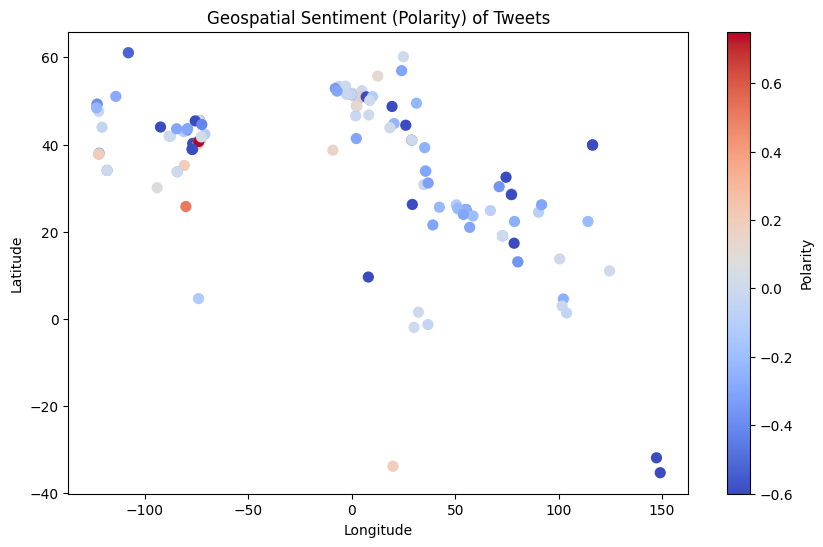

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    location_sentiment['longitude'],
    location_sentiment['latitude'],
    c=location_sentiment['polarity'],
    cmap='coolwarm',
    s=50
)

plt.colorbar(label='Polarity')
plt.title("Geospatial Sentiment (Polarity) of Tweets")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## TASK 2.4

In [115]:
# Calculate subjectivity
tweets_sample['subjectivity'] = tweets_sample['clean_tweet'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

In [116]:
tweets_sample.columns


Index(['tweet', 'user_location', 'user_followers', 'user_verified',
       'clean_tweet', 'latitude', 'longitude', 'polarity', 'subjectivity'],
      dtype='str')

In [117]:
# Display sample results to verify subjectivity values

tweets_sample[['clean_tweet', 'subjectivity']].head()

,clean_tweet,subjectivity
0,interesting read models for using to make,0.5
1,,0.0
2,how artificial intelligence will redefine mana...,1.0
3,the advertising industry shouldnt fear ai it s...,0.0
4,artificial intelligence legal ethical and poli...,0.6


In [118]:
# Group tweets by user location and calculate average subjectivity
# This helps analyse how opinion-based content varies by region

location_subjectivity = tweets_sample.groupby('user_location')['subjectivity'].mean().reset_index()

In [119]:
# Merge subjectivity results with geographical coordinates
# This allows us to plot subjectivity on a map

location_subjectivity = location_subjectivity.merge(
    tweets_sample[['user_location', 'latitude', 'longitude']].drop_duplicates(),
    on='user_location',
    how='left'
)

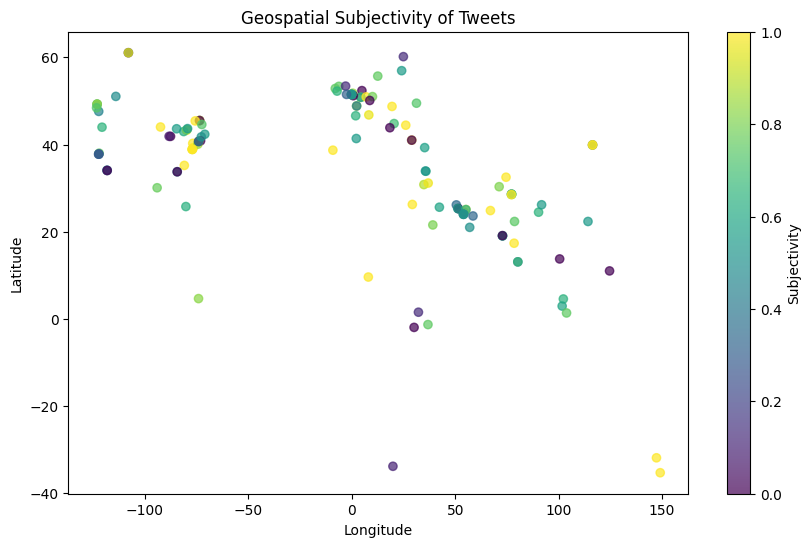

In [120]:
import matplotlib.pyplot as plt

# Create figure for better visualization
plt.figure(figsize=(10,6))

# Plot subjectivity values on map using scatter plot
# Color represents subjectivity level

plt.scatter(
    location_subjectivity['longitude'],
    location_subjectivity['latitude'],
    c=location_subjectivity['subjectivity'],
    cmap='viridis',   # color scale
    alpha=0.7         # transparency for better visibility
)

# Add color bar to explain subjectivity scale
plt.colorbar(label='Subjectivity')

# Add titles and labels
plt.title("Geospatial Subjectivity of Tweets")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Display plot
plt.show()

In [121]:
# Check overall subjectivity statistics

location_subjectivity['subjectivity'].describe()

count    133.000000
mean       0.590269
std        0.329951
min        0.000000
25%        0.416667
50%        0.616667
75%        0.850000
max        1.000000
Name: subjectivity, dtype: float64

# Task 2.5

## Story & Interpretation 
This analysis aimed to explore public sentiment towards artificial intelligence (AI) using geospatial data derived from Twitter. The study involved preprocessing tweet data, extracting user locations, performing geocoding, and applying sentiment and subjectivity analysis techniques to understand how opinions vary across different geographical regions 

The geocoding process enabled the transformation of textual user locations into geographical coordinates (latitude and longitude), allowing for spatial analysis. To improve efficiency, geocoding was applied to unique location values only, reducing redundant API calls and avoiding rate limitations. The results were then merged back into the full dataset, ensuring that all tweets were associated with geographic information.

Sentiment analysis was conducted using the TextBlob library, which assigns polarity scores ranging from -1 (negative sentiment) to +1 (positive sentiment). The analysis revealed that sentiment towards AI varies significantly across regions. While some areas showed clusters of positive sentiment, indicating optimism about AI technologies, other regions exhibited more negative or neutral tones, suggesting concerns or uncertainty. This geographical variation highlights how public perception of AI is influenced by regional, cultural, or socio-economic factors.

In addition to polarity, subjectivity analysis was performed to measure how opinion-based or factual the tweets were. Subjectivity scores range from 0 (objective) to 1 (highly subjective). The results indicated that certain regions tend to produce more opinion-driven content, while others share more factual or neutral information. This distinction is important, as highly subjective tweets may reflect personal beliefs or emotional responses, whereas objective tweets may relate more to factual reporting or information sharing.

Despite identifying positive, negative, and mixed sentiments across locations, it is important to consider the reliability of the data. Tweets are often informal, brief, and context-dependent, and may not fully represent broader public opinion. Additionally, user-provided location data may be inconsistent or ambiguous, which can affect geocoding accuracy.

Overall, this analysis demonstrates the value of combining geospatial analysis with natural language processing techniques to gain insights into public opinion. It highlights how sentiment and subjectivity can vary geographically and provides a foundation for further analysis, such as policy-making, market research, or strategic decision-making in AI-related domains.